# Librerías

In [1]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm
from scipy.stats import ttest_rel, wilcoxon, shapiro, levene, t, ttest_ind, chi2_contingency, bootstrap, skewtest
from tabulate import tabulate
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import OLSInfluence
from statsmodels.stats.power import TTestPower
from statsmodels.stats.contingency_tables import mcnemar
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from statsmodels.formula.api import mixedlm
from statsmodels.stats.proportion import proportion_confint
from statsmodels.stats.contingency_tables import cochrans_q
from scipy.stats import chi2

## Semilla

In [2]:
np.random.seed(42)

# Cargo los datos

In [3]:
#!wget https://raw.githubusercontent.com/bitazaratustra/proyecto_gv/main/data/base_ecocardio.csv

df = pd.read_csv('../data/base_ecocardio.csv')
df.shape

(76, 111)

In [4]:
delete_cols = [
    'rumble','DIAL DESD', 'DiastolMITRAL', 'Id1', 'Id', 'ConMS 1', 'VD global', 'POR1', 'Cav 1', 'CONG', 'CEmodsev', 'SUPRAH', 'DIASTOL', 'FEVI',
    'FAV', 'bal 1500', 'bal 1500-3000', 'bal 3000', 'SC', 'SIV', 'PP', 'Acceso',
    'AD dil', 'VD1dil', 'VD2dil', 'VD3dil', 'derra', 'TEy', 'VD global', 'AHF'
]

df.drop(columns=delete_cols, inplace=True)

In [5]:
var_demograficas = ["SEX", "EDAD", "HTA", "DBT", "DLP", "TBQ"]
var_medicacion = ["BB", "BCA", "IECA", "ARA II", "ARNI", "MRA", "SGLT", "INSULINA"]
var_antropometricas = ["PESO", "TALLA", "HTO", "HB", "ALBUMIN", "KtV", "BALANCE"]
var_dialisis = ['POSDIAL']
var_id = ['Paciente']

var_estaticas = var_demograficas + var_medicacion + var_antropometricas + var_dialisis + var_id

var_categoricas = ['NAGUE +','DisfTEI','Disf TAPSE','Disf FAC','Disf Stis','IT','CAVA','PORT','Eeprim VD 6']
var_ordinales = ['IT','CAVA','PORT']
pin_vars = ['SEX', 'HTA', 'DBT', 'DLP', 'TBQ', 'BB', 'BCA', 'IECA', 'ARA II', 'ARNI', 'MRA', 'SGLT', 'INSULINA']

var_numericas = list(
    set(df.columns) 
    - set(var_categoricas) 
    - set(var_ordinales) 
    - set(var_estaticas)
)

In [6]:
encoder = LabelEncoder()
ordinal = OrdinalEncoder()


for col in var_categoricas:
    df[col] = df[col].where(df[col].isna(), encoder.fit_transform(df[col].values.astype(str)))

for col in var_ordinales:
    df[col] = df[col].where(df[col].isna(), ordinal.fit_transform(df[[col]].astype(str))[:, 0])

In [7]:
df_pre = df[df['POSDIAL'] == 0]
df_pos = df[df['POSDIAL'] == 1]

In [11]:
len(df.columns)

82

## Apuntes

In [9]:
# df[(df['IT'] != 0) & (df['vel it'].isna())]

# El paciente 9 tiene diagnosticos de IT pero no se pudo medir PSAP, vel it, y etc. y calculos derivados.
# Por problemas tecnicos no se realizo la medicion de los parametros relacionados con ls IT en el paciente 9.
# Tapse no se mide por carecer de la ventana apropiada
#

# EDA

In [119]:
def generar_tabla1(df, pin_vars):

    # Definir rangos de edad
    bins = [0, 30, 45, 60, 75, 100]
    labels = ['18–30', '31–45', '46–60', '61–75', '76+']
    df['Edad_Rango'] = pd.cut(df['EDAD'], bins=bins, labels=labels, right=False)

    # Filtrar post-diálisis
    df_freq = df[df['POSDIAL'] == 1].copy()

    def get_freq_table(var):
        freq = df_freq[var].value_counts()
        percentage = df_freq[var].value_counts(normalize=True) * 100
        return freq, percentage

    table1_data = []

    for var in pin_vars:
        freq, percentage = get_freq_table(var)
        categories = {
            'SEX': {'F': 'Mujer'},
            'HTA': {1: 'HTA'},
            'DBT': {1: 'Diabetes'},
            'DLP': {1: 'Dislipidemia'},
            'TBQ': {1: 'Tabaquismo'},
            'BB': {1: 'BB'},
            'BCA': {1: 'BCA'},
            'IECA': {1: 'IECA'},
            'ARA II': {1: 'ARA II'},
            'ARNI': {1: 'ARNI'},
            'MRA': {1: 'MRA'},
            'SGLT': {1: 'SGLT'},
            'INSULINA': {1: 'INSULINA'}
        }.get(var, {})

        for category, freq_val in freq.items():
            if category in categories:
                name = categories[category]
                table1_data.append([var, name, freq_val, f"{percentage[category]:.2f}%"])

        # Agregar 0s explícitos
        missing = set(categories.values()) - set([categories[c] for c in freq.index if c in categories])
        for miss in missing:
            table1_data.append([var, miss, 0, "0.00%"])

    # Edad
    age_freq, age_percentage = get_freq_table('Edad_Rango')
    for age, freq_val in age_freq.items():
        table1_data.append(["EDAD", f"{age}", freq_val, f"{age_percentage[age]:.2f}%"])

    df.drop(columns='Edad_Rango', inplace=True)

    # Mapeo de dominios
    dominio_map = {
        "SEX": "Sexo",
        "EDAD": "Edad",
        "HTA": "Comorbilidades", "DBT": "Comorbilidades", "DLP": "Comorbilidades", "TBQ": "Comorbilidades",
        "BB": "Medicación Crónica", "BCA": "Medicación Crónica", "IECA": "Medicación Crónica",
        "ARA II": "Medicación Crónica", "ARNI": "Medicación Crónica", "MRA": "Medicación Crónica",
        "SGLT": "Medicación Crónica", "INSULINA": "Medicación Crónica"
    }

    df_table = pd.DataFrame(table1_data, columns=["Var", "Categoría", "Frecuencia Abs", "Frecuencia Relativa (%)"])
    df_table["Dominio"] = df_table["Var"].map(dominio_map)
    df_table["n (%)"] = df_table["Frecuencia Abs"].astype(str) + " (" + df_table["Frecuencia Relativa (%)"] + ")"

    # Construir tabla final con estructura vertical jerárquica
    final_rows = []
    for dominio in ["Sexo", "Edad", "Comorbilidades", "Medicación Crónica"]:
        final_rows.append([f"**{dominio.upper()}**", ""])  # encabezado de sección
        subdf = df_table[df_table["Dominio"] == dominio]
        subdf = subdf.sort_values(by="Categoría")
        for _, row in subdf.iterrows():
            final_rows.append([f"    {row['Categoría']}", row["n (%)"]])  # categoría indentada

    tabla_final = pd.DataFrame(final_rows, columns=["Características basales", "n (%)"])
    return tabla_final


In [120]:
generar_tabla1(df, pin_vars)

,Características basales,n (%)
0,**SEXO**,
1,Mujer,15 (39.47%)
2,**EDAD**,
3,18–30,5 (13.16%)
4,31–45,9 (23.68%)
5,46–60,17 (44.74%)
6,61–75,5 (13.16%)
7,76+,2 (5.26%)
8,**COMORBILIDADES**,
9,Diabetes,11 (28.95%)


## Función Análisis de Variables Categóricas

In [1]:
#############################################
# Funciones para análisis de variables categóricas
#############################################

def analisis_categorico(variable, tipo='binaria'):
    """
    Realiza análisis descriptivo, gráfico e inferencial de una variable categórica pre vs post diálisis.

    Parameters:
    - variable: nombre de la columna a analizar
    - tipo: 'binaria' o 'politomica'

    Returns:
    - tabla de contingencia (DataFrame)
    """
    # 1. Preparación de datos
    df_wide = df.pivot_table(index='Paciente',
                              columns='POSDIAL',
                              values=variable,
                              aggfunc='first').dropna()
    df_wide.columns = ['Pre', 'Post']

    print("\n" + "="*50)
    print(f"Análisis para variable: {variable}")
    print("="*50)

    # 2. Descriptivo y gráficos
    for momento in ['Pre', 'Post']:
        temp = df_wide[momento]
        freq = temp.value_counts()
        prop = temp.value_counts(normalize=True)

        print(f"\nFrecuencias {momento}-Diálisis:")
        print(freq)
        print(f"\nProporciones {momento}-Diálisis:")
        print(prop.round(3))

        plt.figure(figsize=(6, 4))
        freq.plot(kind='bar')  # usa paleta por defecto
        plt.title(f'Distribución {momento}-Diálisis: {variable}')
        plt.xlabel('Categorías')
        plt.ylabel('Frecuencia')
        plt.xticks(rotation=45 if tipo == 'politomica' else 0)
        plt.tight_layout()
        plt.show()

    # 3. Matriz de transiciones
    tabla = pd.crosstab(df_wide['Pre'], df_wide['Post'])
    print("\nTabla de contingencia completa:")
    print(tabla)

    plt.figure(figsize=(8, 6))
    sns.heatmap(tabla,
                annot=True,
                fmt='d',
                cmap='Blues',
                cbar_kws={'label': 'Número de pacientes'},
                linewidths=0.5)
    plt.title(f'Matriz de Transiciones: {variable}', pad=20)
    plt.xlabel('Post-diálisis')
    plt.ylabel('Pre-diálisis')
    plt.xticks(rotation=45 if tipo == 'politomica' else 0)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # 4. Análisis inferencial
    if tipo == 'binaria':
        # McNemar exacto
        resultado = mcnemar(tabla, exact=True)
        b = tabla.iloc[0, 1]
        c = tabla.iloc[1, 0]
        or_val = b / c if c != 0 else np.inf
        ci_low, ci_high = proportion_confint(count=b, nobs=b + c, method='beta')

        print("\nResultados inferenciales:")
        print(f"Prueba de McNemar (exacta): p = {resultado.pvalue:.4f}")
        print(f"OR (IC95% beta exacto): {or_val:.2f} ({ci_low:.2f}-{ci_high:.2f})")

    else:
        # Bowker's test de simetría
        chi2_stat = 0
        categorias = tabla.index.tolist()
        for i in range(len(categorias)):
            for j in range(i+1, len(categorias)):
                nij = tabla.iloc[i, j]
                nji = tabla.iloc[j, i]
                denom = nij + nji
                if denom > 0:
                    chi2_stat += (nij - nji)**2 / denom
        df_dof = len(categorias) * (len(categorias) - 1) / 2
        p_val = 1 - chi2.cdf(chi2_stat, df_dof)

        print("\nResultados inferenciales:")
        print(f"Prueba de Bowker: χ² = {chi2_stat:.2f}, df = {int(df_dof)}, p = {p_val:.4f}")

        # Análisis post-hoc con McNemar exacto para cada par
        resultados_posthoc = []
        for i in range(len(categorias)):
            for j in range(i+1, len(categorias)):
                sub_tabla = tabla.iloc[[i, j], [i, j]]
                b = sub_tabla.iloc[0, 1]
                c = sub_tabla.iloc[1, 0]
                p_sub = mcnemar(sub_tabla, exact=True).pvalue
                or_sub = b / c if c != 0 else np.inf
                resultados_posthoc.append({'Par': f"{categorias[i]} vs {categorias[j]}",
                                          'OR': or_sub,
                                          'p_valor': p_sub})

        if resultados_posthoc:
            pvals = [r['p_valor'] for r in resultados_posthoc]
            rejected, pvals_corr, _, _ = multipletests(pvals, method='fdr_bh')

            print("\nAnálisis post-hoc con corrección FDR:")
            for idx, res in enumerate(resultados_posthoc):
                print(f"{res['Par']}: OR = {res['OR']:.2f}, p = {pvals_corr[idx]:.4f}")

    return tabla

### Eeprim VD 6


Análisis para variable: Eeprim VD 6

Frecuencias Pre-Diálisis:
Pre
1.0    26
0.0    11
Name: count, dtype: int64

Proporciones Pre-Diálisis:
Pre
1.0    0.703
0.0    0.297
Name: proportion, dtype: float64


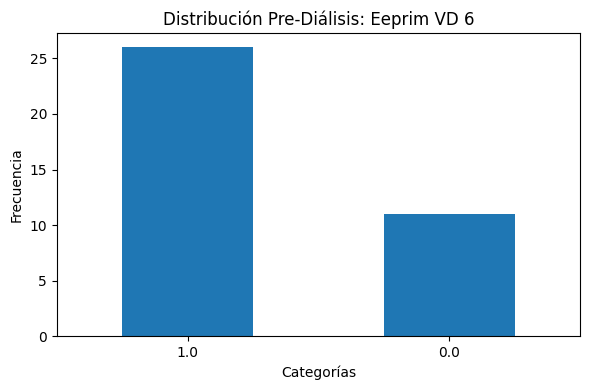


Frecuencias Post-Diálisis:
Post
1.0    21
0.0    16
Name: count, dtype: int64

Proporciones Post-Diálisis:
Post
1.0    0.568
0.0    0.432
Name: proportion, dtype: float64


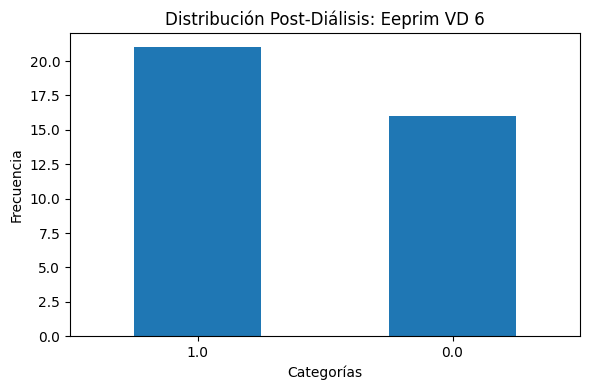


Tabla de contingencia completa:
Post  0.0  1.0
Pre           
0.0     8    3
1.0     8   18


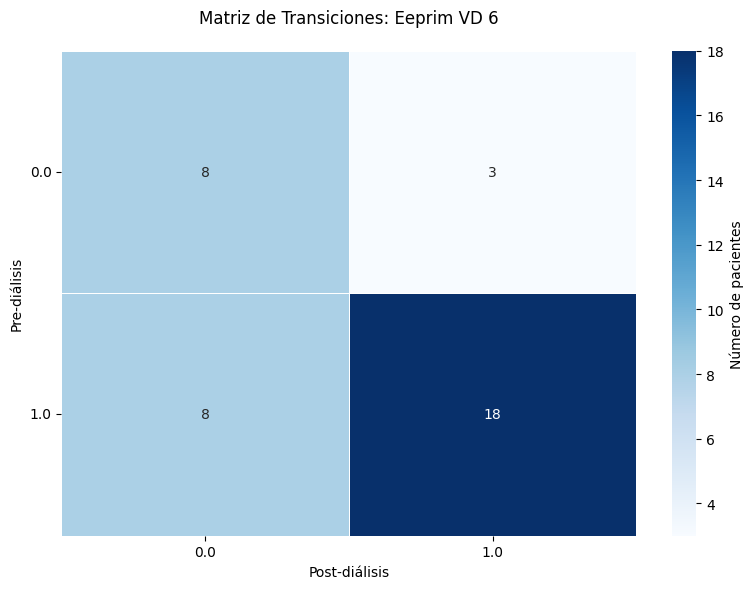


Resultados inferenciales:
Prueba de McNemar (exacta): p = 0.2266
OR (IC95% beta exacto): 0.38 (0.06-0.61)


Post,0.0,1.0
Pre,,
0.0,8,3
1.0,8,18


In [14]:
analisis_categorico('Eeprim VD 6', 'binaria')

### Nague +


Análisis para variable: NAGUE +

Frecuencias Pre-Diálisis:
Pre
1    22
0    16
Name: count, dtype: int64

Proporciones Pre-Diálisis:
Pre
1    0.579
0    0.421
Name: proportion, dtype: float64


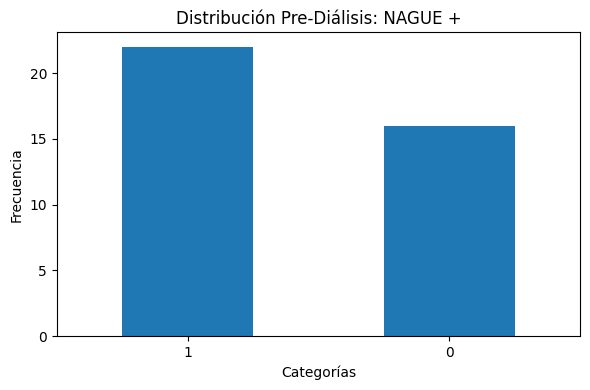


Frecuencias Post-Diálisis:
Post
0    26
1    12
Name: count, dtype: int64

Proporciones Post-Diálisis:
Post
0    0.684
1    0.316
Name: proportion, dtype: float64


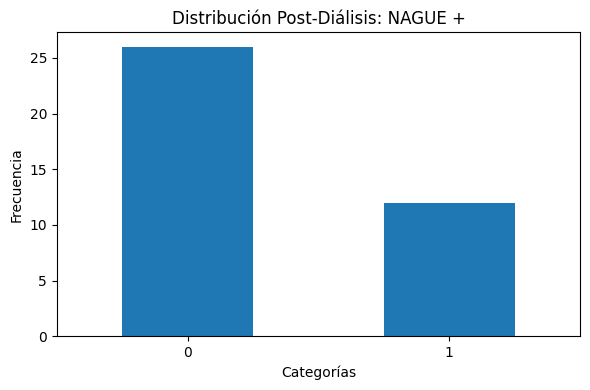


Tabla de contingencia completa:
Post   0   1
Pre         
0     16   0
1     10  12


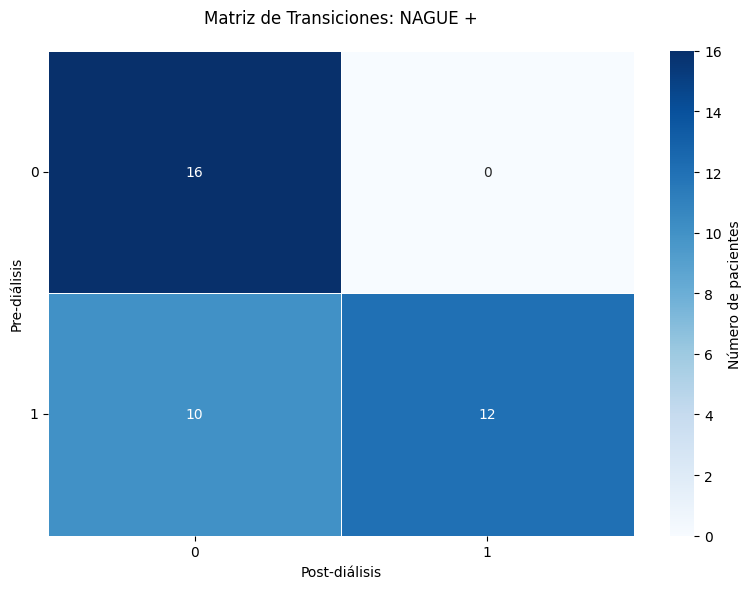


Resultados inferenciales:
Prueba de McNemar (exacta): p = 0.0020
OR (IC95% beta exacto): 0.00 (0.00-0.31)


Post,0,1
Pre,,
0,16,0
1,10,12


In [15]:
analisis_categorico('NAGUE +', 'binaria')

### DisfTEI


Análisis para variable: DisfTEI

Frecuencias Pre-Diálisis:
Pre
1.0    26
0.0    11
Name: count, dtype: int64

Proporciones Pre-Diálisis:
Pre
1.0    0.703
0.0    0.297
Name: proportion, dtype: float64


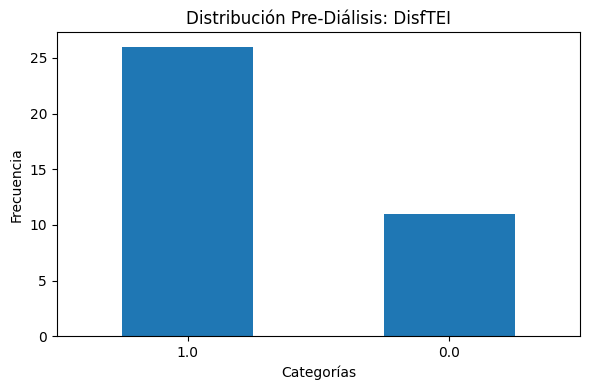


Frecuencias Post-Diálisis:
Post
1.0    23
0.0    14
Name: count, dtype: int64

Proporciones Post-Diálisis:
Post
1.0    0.622
0.0    0.378
Name: proportion, dtype: float64


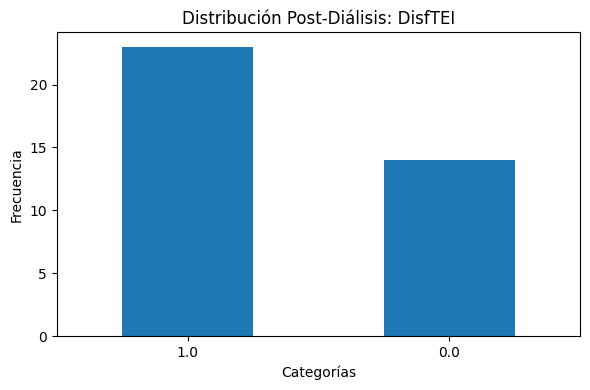


Tabla de contingencia completa:
Post  0.0  1.0
Pre           
0.0     7    4
1.0     7   19


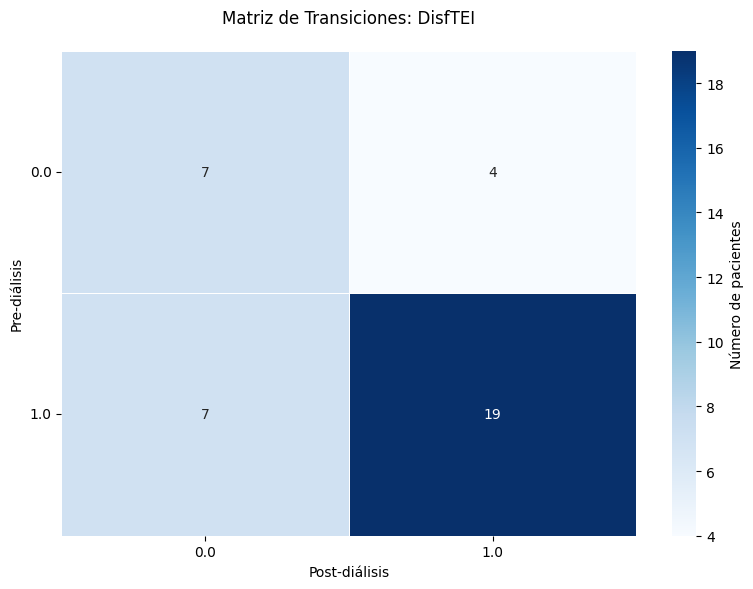


Resultados inferenciales:
Prueba de McNemar (exacta): p = 0.5488
OR (IC95% beta exacto): 0.57 (0.11-0.69)


Post,0.0,1.0
Pre,,
0.0,7,4
1.0,7,19


In [16]:
analisis_categorico('DisfTEI', 'binaria')

### Disf TAPSE


Análisis para variable: Disf TAPSE

Frecuencias Pre-Diálisis:
Pre
1.0    32
0.0     5
Name: count, dtype: int64

Proporciones Pre-Diálisis:
Pre
1.0    0.865
0.0    0.135
Name: proportion, dtype: float64


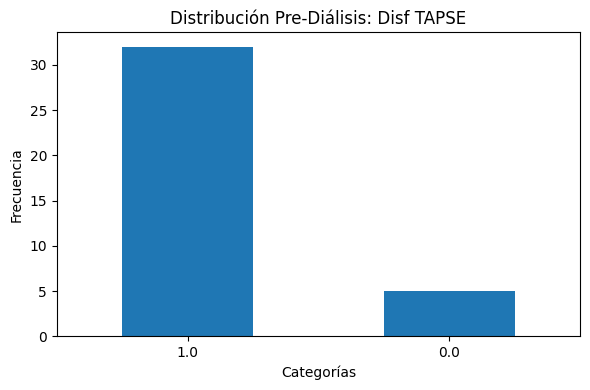


Frecuencias Post-Diálisis:
Post
1.0    29
0.0     8
Name: count, dtype: int64

Proporciones Post-Diálisis:
Post
1.0    0.784
0.0    0.216
Name: proportion, dtype: float64


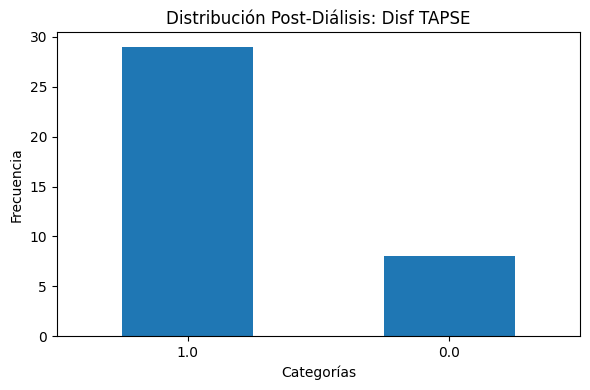


Tabla de contingencia completa:
Post  0.0  1.0
Pre           
0.0     4    1
1.0     4   28


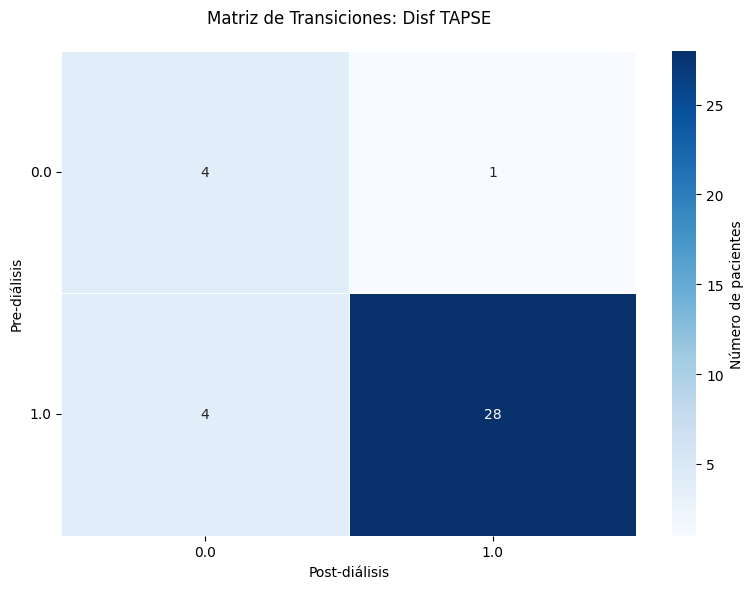


Resultados inferenciales:
Prueba de McNemar (exacta): p = 0.3750
OR (IC95% beta exacto): 0.25 (0.01-0.72)


In [17]:
results = analisis_categorico('Disf TAPSE', 'binaria')

### Disf FAC


Análisis para variable: Disf FAC

Frecuencias Pre-Diálisis:
Pre
1.0    32
0.0     4
Name: count, dtype: int64

Proporciones Pre-Diálisis:
Pre
1.0    0.889
0.0    0.111
Name: proportion, dtype: float64


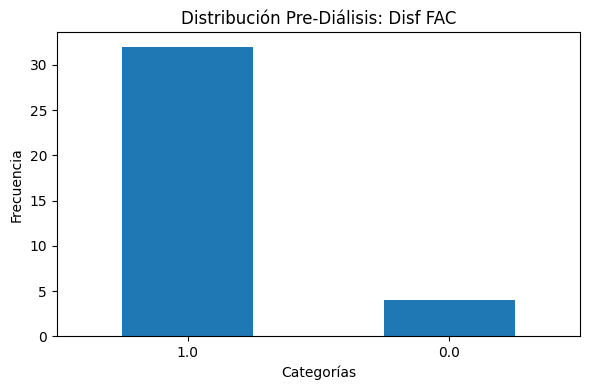


Frecuencias Post-Diálisis:
Post
1.0    30
0.0     6
Name: count, dtype: int64

Proporciones Post-Diálisis:
Post
1.0    0.833
0.0    0.167
Name: proportion, dtype: float64


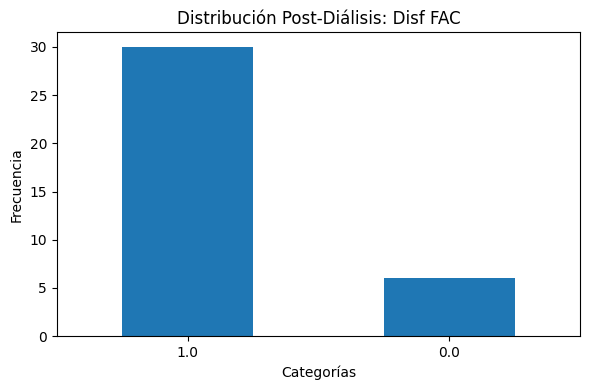


Tabla de contingencia completa:
Post  0.0  1.0
Pre           
0.0     3    1
1.0     3   29


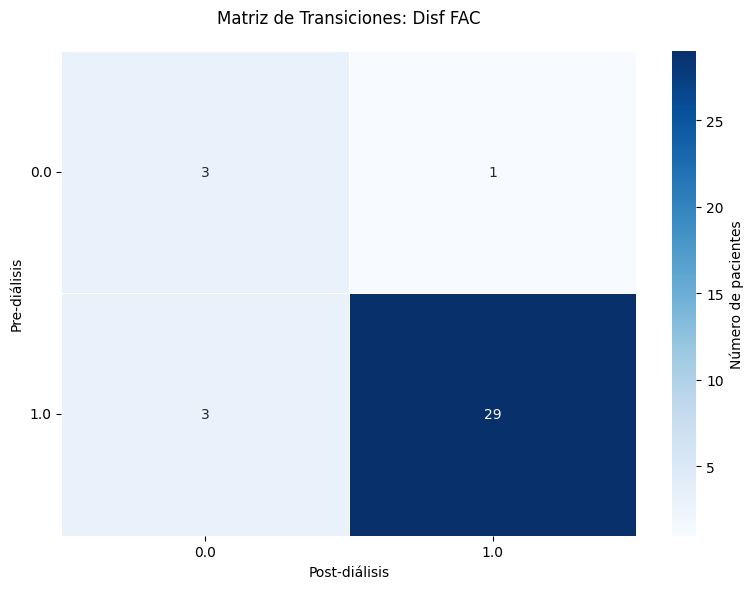


Resultados inferenciales:
Prueba de McNemar (exacta): p = 0.6250
OR (IC95% beta exacto): 0.33 (0.01-0.81)


Post,0.0,1.0
Pre,,
0.0,3,1
1.0,3,29


In [18]:
analisis_categorico('Disf FAC', 'binaria')

### Disf Stis


Análisis para variable: Disf Stis

Frecuencias Pre-Diálisis:
Pre
1.0    31
0.0     6
Name: count, dtype: int64

Proporciones Pre-Diálisis:
Pre
1.0    0.838
0.0    0.162
Name: proportion, dtype: float64


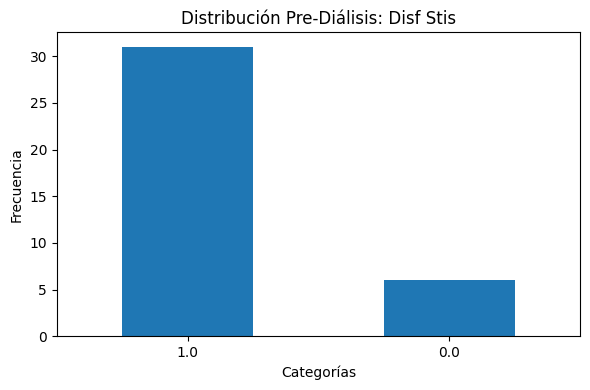


Frecuencias Post-Diálisis:
Post
1.0    24
0.0    13
Name: count, dtype: int64

Proporciones Post-Diálisis:
Post
1.0    0.649
0.0    0.351
Name: proportion, dtype: float64


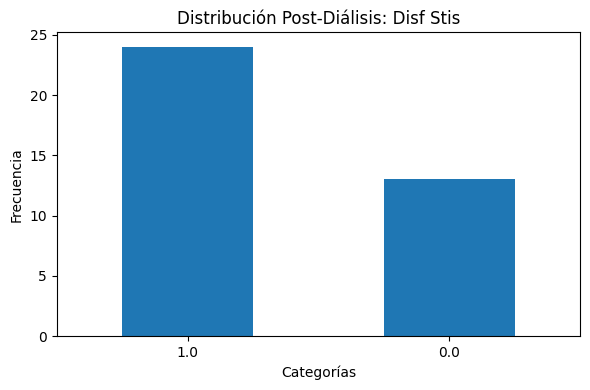


Tabla de contingencia completa:
Post  0.0  1.0
Pre           
0.0     5    1
1.0     8   23


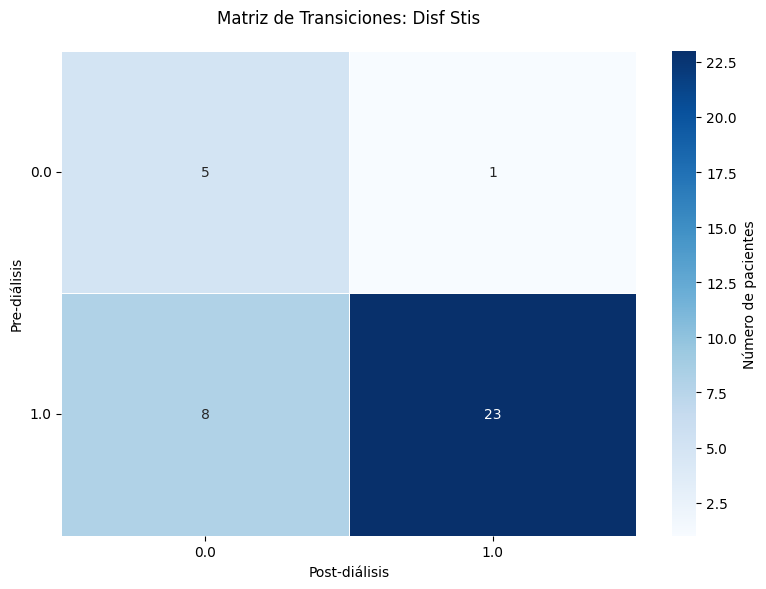


Resultados inferenciales:
Prueba de McNemar (exacta): p = 0.0391
OR (IC95% beta exacto): 0.12 (0.00-0.48)


Post,0.0,1.0
Pre,,
0.0,5,1
1.0,8,23


In [19]:
analisis_categorico('Disf Stis', 'binaria')

### IT


Análisis para variable: IT

Frecuencias Pre-Diálisis:
Pre
1    24
0    12
2     1
3     1
Name: count, dtype: int64

Proporciones Pre-Diálisis:
Pre
1    0.632
0    0.316
2    0.026
3    0.026
Name: proportion, dtype: float64


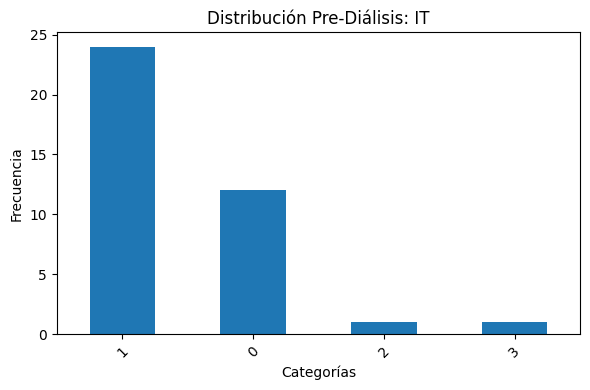


Frecuencias Post-Diálisis:
Post
0    20
1    16
2     1
3     1
Name: count, dtype: int64

Proporciones Post-Diálisis:
Post
0    0.526
1    0.421
2    0.026
3    0.026
Name: proportion, dtype: float64


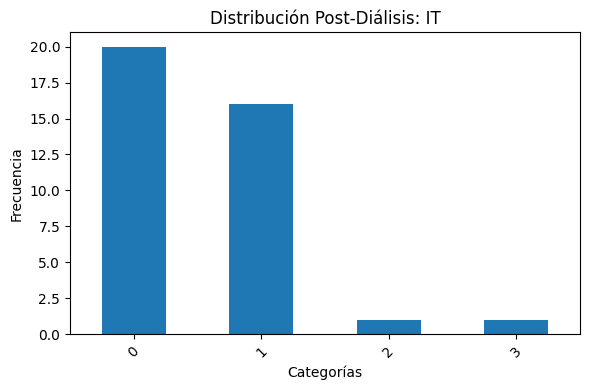


Tabla de contingencia completa:
Post   0   1  2  3
Pre               
0     11   1  0  0
1      9  15  0  0
2      0   0  1  0
3      0   0  0  1


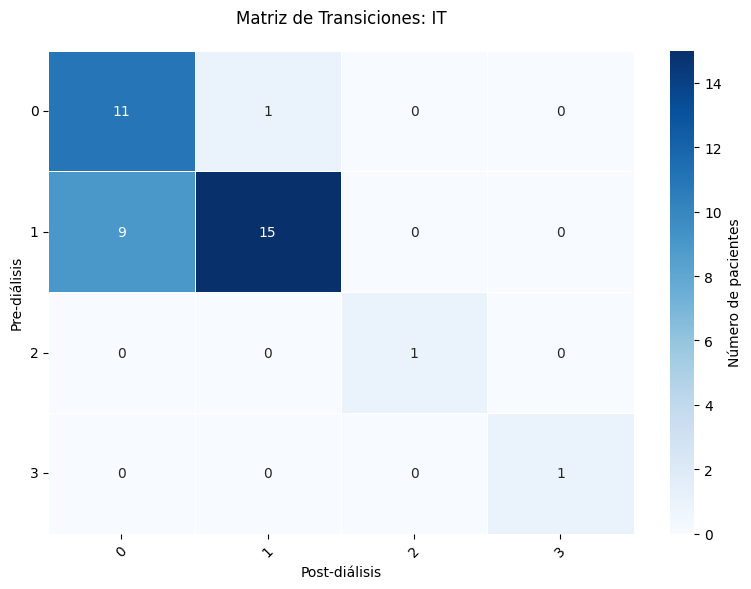


Resultados inferenciales:
Prueba de Bowker: χ² = 6.40, df = 6, p = 0.3799

Análisis post-hoc con corrección FDR:
0 vs 1: OR = 0.11, p = 0.1289
0 vs 2: OR = inf, p = 1.0000
0 vs 3: OR = inf, p = 1.0000
1 vs 2: OR = inf, p = 1.0000
1 vs 3: OR = inf, p = 1.0000
2 vs 3: OR = inf, p = 1.0000


Post,0,1,2,3
Pre,,,,
0,11,1,0,0
1,9,15,0,0
2,0,0,1,0
3,0,0,0,1


In [20]:
analisis_categorico('IT', 'politomica')

### CAVA


Análisis para variable: CAVA

Frecuencias Pre-Diálisis:
Pre
0    15
2    12
1    11
Name: count, dtype: int64

Proporciones Pre-Diálisis:
Pre
0    0.395
2    0.316
1    0.289
Name: proportion, dtype: float64


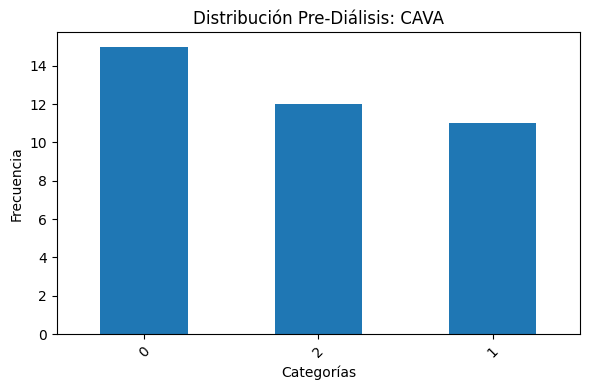


Frecuencias Post-Diálisis:
Post
0    32
2     3
1     3
Name: count, dtype: int64

Proporciones Post-Diálisis:
Post
0    0.842
2    0.079
1    0.079
Name: proportion, dtype: float64


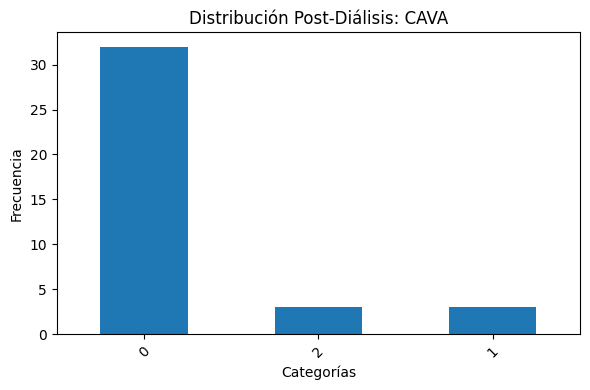


Tabla de contingencia completa:
Post   0  1  2
Pre           
0     15  0  0
1     11  0  0
2      6  3  3


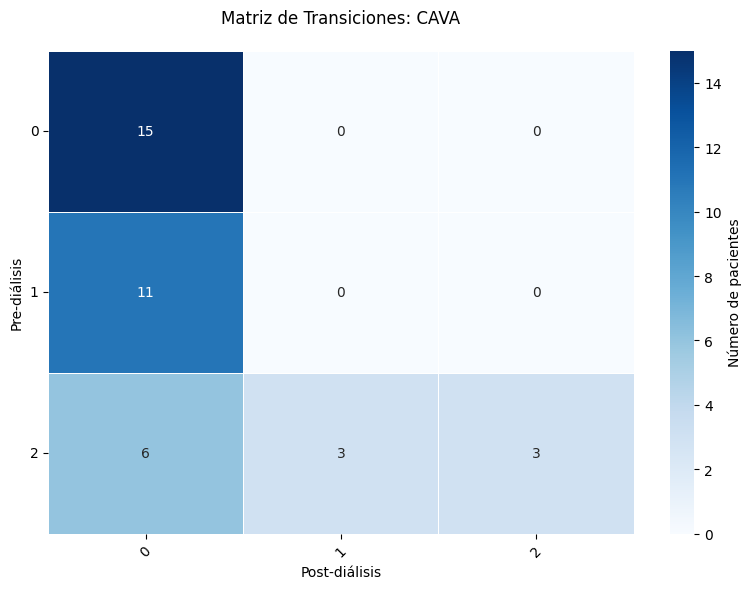


Resultados inferenciales:
Prueba de Bowker: χ² = 20.00, df = 3, p = 0.0002

Análisis post-hoc con corrección FDR:
0 vs 1: OR = 0.00, p = 0.0029
0 vs 2: OR = 0.00, p = 0.0469
1 vs 2: OR = 0.00, p = 0.2500


Post,0,1,2
Pre,,,
0,15,0,0
1,11,0,0
2,6,3,3


In [21]:
analisis_categorico('CAVA', 'politomica')

### PORT


Análisis para variable: PORT

Frecuencias Pre-Diálisis:
Pre
0    15
1    12
2    11
Name: count, dtype: int64

Proporciones Pre-Diálisis:
Pre
0    0.395
1    0.316
2    0.289
Name: proportion, dtype: float64


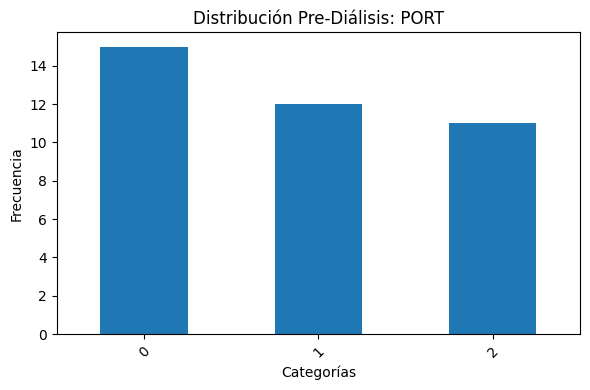


Frecuencias Post-Diálisis:
Post
0    28
1     9
2     1
Name: count, dtype: int64

Proporciones Post-Diálisis:
Post
0    0.737
1    0.237
2    0.026
Name: proportion, dtype: float64


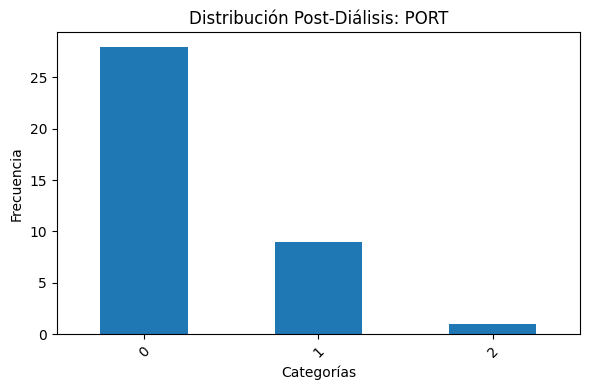


Tabla de contingencia completa:
Post   0  1  2
Pre           
0     15  0  0
1      7  5  0
2      6  4  1


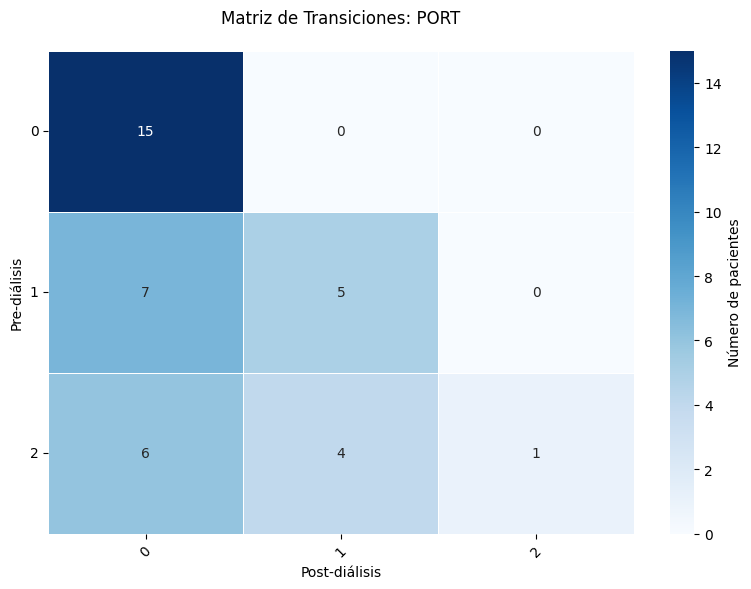


Resultados inferenciales:
Prueba de Bowker: χ² = 17.00, df = 3, p = 0.0007

Análisis post-hoc con corrección FDR:
0 vs 1: OR = 0.00, p = 0.0469
0 vs 2: OR = 0.00, p = 0.0469
1 vs 2: OR = 0.00, p = 0.1250


Post,0,1,2
Pre,,,
0,15,0,0
1,7,5,0
2,6,4,1


In [22]:
analisis_categorico('PORT', 'politomica')

## Funciónes Análisis de Variables Numéricas

### Preparación de datos y selección de variables

In [9]:
def prepare_data(df, var_estaticas, var_categoricas, var_ordinales,
                 var_antropometricas, var_medicacion, var_demograficas,
                 missing_threshold=0.2, verbose=True):
    """
    Selecciona variables numéricas con datos suficientes para análisis pareado pre-post.

    Esta función implementa el criterio de exclusión basado en completitud adaptativa,
    como se describe en la metodología (máximo entre proporción de faltantes pre y post).
    
    Parámetros:
    ----------
    df : pd.DataFrame
        Dataset completo con columnas 'POSDIAL' y 'Paciente'.

    var_estaticas : list
        Lista de variables consideradas constantes (sexo, edad, comorbilidades, etc.).

    var_categoricas : list
        Lista de variables categóricas (dicotómicas o multiclase, no ordinales).

    var_ordinales : list
        Lista de variables categóricas con orden jerárquico (e.g., grados de IT, CAVA).

    var_antropometricas : list
        Peso, talla, y variables de laboratorio basal.

    var_medicacion : list
        Variables de tratamiento farmacológico crónico.

    var_demograficas : list
        Variables demográficas (edad, sexo, tabaquismo, etc.).

    missing_threshold : float, default=0.2
        Umbral máximo tolerado de datos faltantes (entre 0 y 1).

    verbose : bool, default=False
        Si es True, muestra variables excluidas y su tasa de faltantes.

    Retorna:
    -------
    clean_vars : list
        Lista de nombres de variables numéricas seleccionadas para análisis pareado.
    """
    # Construcción del conjunto de variables no numéricas (exclusión)
    no_numericas = (var_estaticas + var_categoricas + var_ordinales +
                    var_antropometricas + var_medicacion + var_demograficas)

    # Variables candidatas a ser numéricas para análisis longitudinal
    initial_vars = [
        v for v in df.columns 
        if v not in no_numericas + ['Paciente', 'POSDIAL']
    ]

    # Evaluación del patrón de faltantes pre y post
    clean_vars = []
    for v in initial_vars:
        miss_pre = df[df['POSDIAL'] == 0][v].isna().mean()
        miss_post = df[df['POSDIAL'] == 1][v].isna().mean()
        max_missing = max(miss_pre, miss_post)
        if max_missing <= missing_threshold:
            clean_vars.append(v)
        elif verbose:
            print(f"⚠️ Variable excluida: {v} - faltantes pre: {miss_pre:.2%}, post: {miss_post:.2%}")

    return clean_vars

In [125]:
vars_validas = prepare_data(df, var_estaticas, var_categoricas, var_ordinales,
                            var_antropometricas, var_medicacion, var_demograficas,
                            missing_threshold=1, verbose=True)

### Escalado de variables numéricas

In [126]:
from sklearn.preprocessing import StandardScaler

def scale_variables(df, var_numericas):
    """
    Escala estandarizada (Z-score) de variables numéricas dinámicas.

    Esta función implementa la transformación z-score descrita en la metodología,
    generando una versión estandarizada de cada variable numérica seleccionada.
    La estandarización permite:
        (1) Comparabilidad dimensional entre variables,
        (2) Detección de sesgos inducidos por escala,
        (3) Análisis paralelo con y sin transformación.
    
    Se conservan las columnas 'Paciente' y 'POSDIAL' para mantener la estructura longitudinal.

    Parámetros:
    ----------
    df : pd.DataFrame
        DataFrame completo, con columnas 'Paciente' y 'POSDIAL'.

    var_numericas : list
        Lista de variables numéricas dinámicas (filtradas por `prepare_data`).

    Retorna:
    -------
    df_z : pd.DataFrame
        Nuevo DataFrame con columnas:
            - 'Paciente'
            - 'POSDIAL'
            - Variables estandarizadas con sufijo '_z'
    """
    # 1. Extraer columnas de identificación
    df_base = df[['Paciente', 'POSDIAL']].reset_index(drop=True)

    # 2. Estandarizar variables numéricas
    scaler = StandardScaler()
    z_data = scaler.fit_transform(df[var_numericas])
    df_z_vars = pd.DataFrame(z_data, columns=[f"{v}_z" for v in var_numericas])

    # 3. Concatenar identificadores + variables Z
    df_z = pd.concat([df_base, df_z_vars], axis=1)

    return df_z

In [128]:
df_z = scale_variables(df, var_numericas=vars_validas)

### Análisis de valores faltantes

In [12]:
def analyze_missing_data(df, variables, covariates, return_raw=False):
    """
    Analiza patrones de datos faltantes y su asociación con covariables (MCAR).

    Parámetros:
    -----------
    df : pd.DataFrame
        Dataset con columnas 'Paciente' y 'POSDIAL'.

    variables : list
        Lista de variables a evaluar por patrones de valores faltantes.

    covariates : list
        Lista de covariables categóricas o numéricas a testear contra MCAR.

    return_raw : bool, default=False
        Si es True, devuelve además un diccionario detallado por variable.

    Retorna:
    --------
    summary_df : pd.DataFrame
        Tabla resumen con porcentaje de faltantes y p-valores de MCAR.

    raw_results (opcional) : dict
        Resultados completos por variable (si return_raw=True).
    """
    missing_summary = []
    raw_results = {}
    total_pats = df['Paciente'].nunique()

    for var in variables:
        pre_m = df[df['POSDIAL'] == 0][var].isna().sum()
        post_m = df[df['POSDIAL'] == 1][var].isna().sum()
        merged = df.pivot_table(index='Paciente', columns='POSDIAL', values=var, aggfunc='first')
        paired_n = merged.dropna().shape[0]

        mcar_results = {}
        significant_vars = []

        for cov in covariates:
            try:
                if df[cov].dtype == 'object' or df[cov].nunique() < 5:
                    table = pd.crosstab(df[var].isna(), df[cov])
                    _, p, _, _ = chi2_contingency(table)
                else:
                    p = ttest_ind(df[df[var].notna()][cov], df[df[var].isna()][cov], equal_var=False).pvalue
                mcar_results[cov] = p

                if p < 0.05:
                    significant_vars.append(cov)
            except Exception as e:
                mcar_results[cov] = None

        summary_row = {
            'Variable': var,
            'Pacientes Totales': total_pats,
            'Pre-Missing (%)': f"{pre_m / total_pats * 100:.1f}%",
            'Post-Missing (%)': f"{post_m / total_pats * 100:.1f}%",
            'Pares Completos': paired_n,
            **{f'MCAR_{cov} (p)': f"{mcar_results[cov]:.3f}" if mcar_results[cov] is not None else "Error"
               for cov in covariates},
            'Significativas (p<0.05)': ', '.join(significant_vars) if significant_vars else 'Ninguna'
        }

        missing_summary.append(summary_row)
        if return_raw:
            raw_results[var] = {
                'pre_missing_n': pre_m,
                'post_missing_n': post_m,
                'paired_complete': paired_n,
                'mcar_pvalues': mcar_results,
                'significant_covariates': significant_vars
            }

    summary_df = pd.DataFrame(missing_summary)
    return (summary_df, raw_results) if return_raw else summary_df

In [13]:
analyze_missing_data(df, vars_validas, pin_vars)

NameError: name 'vars_validas' is not defined

### Cálculo de tamaño muestral

In [179]:
def compute_sample_size(df, variable, alpha=0.05, power=0.8):
    """
    Calcula tamaño muestral requerido para detectar una diferencia pre-post con potencia deseada.

    Parámetros:
    -----------
    df : pd.DataFrame
        Dataset con columnas 'Paciente', 'POSDIAL' y la variable seleccionada.

    variable : str
        Nombre de la variable numérica a evaluar.

    alpha : float
        Nivel de significancia (por defecto 0.05).

    power : float
        Potencia estadística deseada (por defecto 0.8).

    Retorna:
    --------
    dict
        Información detallada:
            - tamaño muestral requerido
            - diferencia media
            - desviación estándar de diferencias
            - tamaño de efecto (Cohen's d)
            - número actual de pares completos
    """
    merged = df.pivot(index='Paciente', columns='POSDIAL', values=variable).dropna()
    diffs = merged[1] - merged[0]

    if len(diffs) < 2:
        return {
            'Variable': variable,
            'Error': 'Insuficientes pares completos para cálculo'
        }

    mean_diff = diffs.mean()
    std_diff = diffs.std(ddof=1)
    effect_size = mean_diff / std_diff

    power_analysis = TTestPower()
    n_required = power_analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power, alternative='two-sided')

    return {
        'Variable': variable,
        'Pares Completos Actuales': len(diffs),
        'Diferencia Media': round(mean_diff, 3),
        'Desvío Std de Diferencias': round(std_diff, 3),
        'Cohen\'s d': round(effect_size, 3),
        'N Requerido (potencia={:.0%})'.format(power): math.ceil(n_required)
    }

In [180]:
for variable in var_numericas:
    sample_size = compute_sample_size(df, variable)
    print(f"Tamaño de muestra para {variable}: {sample_size}")


Tamaño de muestra para VTI: 17
Tamaño de muestra para IVS: 19
Tamaño de muestra para Eprim: 20
Tamaño de muestra para FC: 8849
Tamaño de muestra para AD: 16
Tamaño de muestra para Eeprim VD: 518
Tamaño de muestra para TapPsap: 12
Tamaño de muestra para PSAP: 7
Tamaño de muestra para IC: 18
Tamaño de muestra para EA VD: 44
Tamaño de muestra para DSVI: 30
Tamaño de muestra para Portmx: 103
Tamaño de muestra para Anillo: 42
Tamaño de muestra para EVD: 13
Tamaño de muestra para EtisVD: 18
Tamaño de muestra para TdecVD: 290
Tamaño de muestra para VD1: 44
Tamaño de muestra para vel it: 9
Tamaño de muestra para StisVD: 28
Tamaño de muestra para FEy: 47
Tamaño de muestra para TEI: 2472
Tamaño de muestra para AI vol index: 5
Tamaño de muestra para A: 72
Tamaño de muestra para Portmin: 62
Tamaño de muestra para Colap: 11
Tamaño de muestra para TAM: 19
Tamaño de muestra para VD2: 134
Tamaño de muestra para AI: 5
Tamaño de muestra para VS: 20
Tamaño de muestra para Tdec: 41
Tamaño de muestra para 

### Bootstrapping BCa

In [14]:
def bootstrap_bca_ci(merged, n_iter=1000, alpha=0.05):
    """
    Calcula intervalo de confianza BCa para la diferencia media pre-post.

    Parámetros:
    -----------
    merged : pd.DataFrame
        DataFrame con columnas 'pre' y 'post', indexado por 'Paciente'.

    n_iter : int, default=1000
        Número de remuestreos bootstrap.

    alpha : float, default=0.05
        Nivel de significancia (para IC 1-alpha).

    Retorna:
    --------
    dict
        Intervalo de confianza BCa para la diferencia (post - pre).
    """
    data = (merged['post'].values, merged['pre'].values)

    def paired_diff(post, pre):
        return np.mean(post - pre)

    res = bootstrap(
        data,
        paired_diff,
        paired=True,
        n_resamples=n_iter,
        method='BCa',
        confidence_level=1 - alpha
    )

    return {
        'IC_BCa_lower': round(res.confidence_interval.low, 3),
        'IC_BCa_upper': round(res.confidence_interval.high, 3),
        'n_bootstrap': n_iter
    }



### Modelo mixto

In [15]:
import pandas as pd
from statsmodels.formula.api import mixedlm

def run_mixed_model(df, variable):
    """
    Ajusta modelo lineal mixto con intercepto aleatorio por paciente.

    Fórmula: Yij = β0 + β1*POSDIALij + ui + εij

    Parámetros:
    -----------
    df : pd.DataFrame
        Dataset con columnas 'Paciente', 'POSDIAL' y la variable a modelar.

    variable : str
        Nombre de la variable dependiente (numérica).

    Retorna:
    --------
    dict
        Resultados del modelo:
            - efecto promedio (β1)
            - intervalo de confianza 95%
            - p-valor
            - residuos y valores ajustados (para diagnóstico gráfico)
    """
    # Limpieza de nombres y preparación
    safe_var = variable.replace(' ', '_')
    tmp = df.rename(columns={variable: safe_var}).dropna(subset=[safe_var])

    # Ajuste del modelo
    model = mixedlm(f'Q("{safe_var}") ~ POSDIAL', data=tmp, groups=tmp['Paciente']).fit(reml=True)

    # Extraer intervalo de confianza del efecto fijo (POSDIAL)
    ci = model.conf_int().loc['POSDIAL']

    return {
        'Variable': variable,
        'Efecto POSDIAL (β1)': round(model.params['POSDIAL'], 3),
        'IC 95% Inferior': round(ci[0], 3),
        'IC 95% Superior': round(ci[1], 3),
        'p-value': round(model.pvalues['POSDIAL'], 4),
        'N Observaciones': int(tmp.shape[0]),
        'Residuos': model.resid,
        'Fitted': model.fittedvalues,
        'Modelo': model  # opcional, para explorar luego
    }


### Analisis Pareado y Plots

### Chequeo de supuestos y selección de prueba

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import ttest_rel, wilcoxon, shapiro, levene, skewtest
from statsmodels.stats.power import TTestPower

plt.style.use('ggplot')
sns.set_palette(["#2E86AB", "#D7263D"])

def paired_analysis_full(df, df_z, variable, covariates=None, alpha=0.05, verbose=True):
    """
    Realiza análisis completo pre-post:
        - Validación de supuestos
        - Selección de prueba estadística
        - Efecto y tamaño muestral
        - Modelo mixto
        - Visualizaciones (histograma, boxplot, dispersión, Bland-Altman)

    Parámetros:
    -----------
    df : DataFrame original
    df_z : DataFrame con variables estandarizadas (no se usa actualmente)
    variable : str
        Nombre de la variable a analizar.
    covariates : list
        Lista de covariables para análisis de sensibilidad (no se usa aquí).
    alpha : float
        Nivel de significancia.
    verbose : bool
        Si True, imprime resultados.

    Retorna:
    --------
    dict
        Resultados numéricos del análisis.
    """
    # Preparación
    merged = df.pivot_table(index='Paciente', columns='POSDIAL', values=variable, aggfunc='first').dropna()
    pre, post = merged[0], merged[1]
    diffs = post - pre

    # Supuestos
    assumptions = check_assumptions_extended(pre, post, alpha)
    if verbose:
        print(f"\n--- SUPUESTOS ---")
        print(f"Normalidad (Shapiro): p = {assumptions['p_shapiro']}")
        print(f"Homocedasticidad (Levene): p = {assumptions['p_levene']}")
        if not assumptions['normal']:
            print(f"Asimetría (Skewtest): p = {assumptions['p_skew']}")

    # Prueba estadística
    test_res = select_paired_test_extended(pre, post, assumptions)
    if verbose:
        print(f"\n--- PRUEBA ESTADÍSTICA ---")
        print(f"Método: {test_res['method']}")
        if 'pvalue' in test_res:
            print(f"p-valor: {test_res['pvalue']}")
        else:
            print(f"IC95% (Bootstrap BCa): [{test_res['IC_BCa_lower']}, {test_res['IC_BCa_upper']}]")

    # Efecto y potencia
    d = compute_effect_size(pre, post)
    n_req = compute_sample_size_from_diffs(pre, post, alpha, 0.8)
    power_obs = TTestPower().solve_power(effect_size=d, alpha=alpha, nobs=len(pre), alternative='two-sided')
    if verbose:
        print(f"\n--- EFECTO Y POTENCIA ---")
        print(f"Cohen's d = {d:.2f}")
        print(f"n requerido (potencia 80%) = {n_req}")
        print(f"Potencia observada = {power_obs:.2f}")

    # Modelo mixto
    mixed = run_mixed_model(df, variable)
    if verbose:
        print(f"\n--- MODELO MIXTO ---")
        print(f"β POSDIAL = {mixed['Efecto POSDIAL (β1)']} (IC95% [{mixed['IC 95% Inferior']}, {mixed['IC 95% Superior']}])")
        print(f"p = {mixed['p-value']}")

    # Gráficos
    fig, axs = plt.subplots(3, 2, figsize=(16, 14))

    # --- 1) Histograma Pre y Post
    sns.histplot(pre, ax=axs[0, 0], color='#2E86AB', kde=True, label='Pre', alpha=0.6)
    sns.histplot(post, ax=axs[0, 0], color='#D7263D', kde=True, label='Post', alpha=0.6)
    axs[0, 0].set_title('Distribución Pre vs Post')
    axs[0, 0].legend()
    
    # --- 2) Box + Swarm
    sns.boxplot(x='Tiempo', y='Valor', data=melted, ax=axs[0, 1], width=0.5)
    sns.swarmplot(x='Tiempo', y='Valor', data=melted, ax=axs[0, 1], color='black', alpha=0.6)
    axs[0, 1].set_title('Comparación Pre-Post')
    axs[0, 1].set_xticklabels(['Pre', 'Post'])
    
    # --- 3) Concordancia
    x_pred = np.linspace(pre.min(), pre.max(), 100)
    modelo = sm.OLS(post, sm.add_constant(pre)).fit()
    y_pred = modelo.predict(sm.add_constant(x_pred))
    pred_int = modelo.get_prediction(sm.add_constant(x_pred)).conf_int()
    palette = sns.diverging_palette(250, 10, sep=80, as_cmap=True)
    vmax = max(abs(diffs.max()), abs(diffs.min()))
    sc = axs[1, 0].scatter(pre, post, c=diffs, cmap=palette, edgecolor='k', s=70, vmin=-vmax, vmax=vmax)
    axs[1, 0].plot([pre.min(), pre.max()], [pre.min(), pre.max()], '--', color='gray', label='Identidad')
    axs[1, 0].plot(x_pred, y_pred, color='black', linewidth=2, label='Regresión')
    axs[1, 0].fill_between(x_pred, pred_int[:, 0], pred_int[:, 1], color='gray', alpha=0.2)
    axs[1, 0].legend()
    axs[1, 0].set_title('Concordancia Pre vs Post')
    plt.colorbar(sc, ax=axs[1, 0], shrink=0.8).set_label('Post - Pre')
    
    # --- 4) Bland-Altman
    avg = (pre + post) / 2
    mean_diff = diffs.mean()
    std_diff = diffs.std(ddof=1)
    axs[1, 1].scatter(avg, diffs, color='#2E86AB', alpha=0.7)
    axs[1, 1].axhline(mean_diff, color='#D7263D', linestyle='--')
    axs[1, 1].axhline(mean_diff + 1.96 * std_diff, color='gray', linestyle=':')
    axs[1, 1].axhline(mean_diff - 1.96 * std_diff, color='gray', linestyle=':')
    axs[1, 1].set_title('Bland-Altman')
    axs[1, 1].text(0.05, 0.95, f'Bias: {mean_diff:.2f}\n±1.96 SD: {1.96 * std_diff:.2f}',
                  transform=axs[1, 1].transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
    
    # --- 5) Q-Q plot de residuos del modelo mixto
    sm.qqplot(mixed['Residuos'], line='45', ax=axs[2, 0], fit=True)
    axs[2, 0].set_title('Q-Q Plot de Residuos (Modelo Mixto)')
    
    # --- 6) Residuos vs Ajustados
    axs[2, 1].scatter(mixed['Fitted'], mixed['Residuos'], alpha=0.6, edgecolor='k')
    axs[2, 1].axhline(0, linestyle='--', color='gray')
    axs[2, 1].set_title('Residuos vs. Ajustados (Modelo Mixto)')
    axs[2, 1].set_xlabel('Valores Ajustados')
    axs[2, 1].set_ylabel('Residuos')
    
    plt.tight_layout()
    plt.show()

    # Resultado final para tabla/reportes
    return {
        'Variable': variable,
        'Test': test_res['method'],
        'p-valor': test_res.get('pvalue'),
        'IC_BCa': (test_res.get('IC_BCa_lower'), test_res.get('IC_BCa_upper')) if 'IC_BCa_lower' in test_res else None,
        'Cohen\'s d': d,
        'n requerido': n_req,
        'Potencia observada': round(power_obs, 3),
        'β mixto': mixed['Efecto POSDIAL (β1)'],
        'p mixto': mixed['p-value'],
        'IC mixto': (mixed['IC 95% Inferior'], mixed['IC 95% Superior'])
    }


In [17]:
from scipy.stats import shapiro, levene, skewtest

def check_assumptions(pre, post, alpha=0.05):
    """
    Evalúa supuestos estadísticos para pruebas pareadas:
        - Normalidad de diferencias (Shapiro-Wilk)
        - Homocedasticidad (Levene)
        - Simetría (skewness test, solo si no normal)

    Parámetros:
    -----------
    pre, post : array-like
        Vectores con mediciones pre y post.

    alpha : float
        Nivel de significancia para las pruebas.

    Retorna:
    --------
    dict
        Incluye flags booleanos y valores p para cada prueba.
    """
    diffs = post - pre
    results = {}

    # Normalidad
    stat_sh, p_shapiro = shapiro(diffs)
    results['normal'] = p_shapiro >= alpha
    results['p_shapiro'] = round(p_shapiro, 4)

    # Homocedasticidad (en comparación cruda pre vs post, no en diferencias)
    stat_lev, p_levene = levene(pre, post, center='median')
    results['homocedastic'] = p_levene >= alpha
    results['p_levene'] = round(p_levene, 4)

    # Simetría (solo si no hay normalidad)
    if not results['normal']:
        stat_skew, p_skew = skewtest(diffs)
        results['symmetric'] = p_skew >= alpha
        results['p_skew'] = round(p_skew, 4)
    else:
        results['symmetric'] = True
        results['p_skew'] = None

    return results


from scipy.stats import ttest_rel, wilcoxon
import numpy as np
import pandas as pd

def select_paired_test(pre, post, assumptions, n_bootstrap=1000):
    """
    Aplica prueba estadística pareada según supuestos:
        - t-test pareado
        - Wilcoxon (si simétrica)
        - Bootstrap BCa (si asimétrica)

    Parámetros:
    -----------
    pre, post : array-like
        Vectores con mediciones pre y post.

    assumptions : dict
        Salida de `check_assumptions_extended`.

    n_bootstrap : int
        Número de remuestreos si se aplica bootstrap.

    Retorna:
    --------
    dict
        Resultado con nombre del test, estadístico y p-valor o IC.
    """
    diffs = post - pre
    n = len(diffs)

    if assumptions['normal']:
        res = ttest_rel(pre, post)
        return {
            'method': 't-test pareado',
            'stat': round(res.statistic, 3),
            'pvalue': round(res.pvalue, 4)
        }
    elif assumptions['symmetric']:
        res = wilcoxon(pre, post, mode='approx')
        # Z-score calculado manualmente
        z = (res.statistic - n*(n+1)/4) / np.sqrt(n*(n+1)*(2*n+1)/24)
        return {
            'method': 'Wilcoxon signed-rank',
            'stat': round(z, 3),
            'pvalue': round(res.pvalue, 4)
        }
    else:
        merged = pd.DataFrame({'pre': pre, 'post': post})
        ci = bootstrap_bca_ci(merged, n_iter=n_bootstrap)
        return {
            'method': 'Bootstrap BCa',
            **ci
        }


def compute_effect_size(pre, post):
    """
    Calcula tamaño del efecto (Cohen's d) para muestras pareadas.

    Retorna:
    --------
    float
        Tamaño del efecto (d).
    """
    diffs = post - pre
    d = diffs.mean() / diffs.std(ddof=1)
    return round(d, 3)
    

def compute_sample_size(pre, post, alpha=0.05, power=0.8):
    """
    Calcula n requerido a partir de diferencias pre-post (pareado).

    Retorna:
    --------
    float o np.nan
        Tamaño muestral requerido (redondeado).
    """
    try:
        d = compute_effect_size(pre, post)
        analysis = TTestPower()
        n = analysis.solve_power(effect_size=d, alpha=alpha, power=power, alternative='two-sided')
        return math.ceil(n)
    except:
        return np.nan

### Ejecución principal

In [ ]:
def run_full_numerical_analysis(df, df_z, variables, covariates=None, alpha=0.05, verbose=True, graficos=True):
    """
    Ejecuta el análisis completo pre-post para un conjunto de variables numéricas dinámicas:
        - Validación de supuestos (Shapiro, Levene, Skew)
        - Selección de test (t, Wilcoxon, Bootstrap)
        - Tamaño del efecto (Cohen’s d)
        - Tamaño muestral necesario
        - Potencia observada
        - Modelo mixto
        - Visualizaciones (opcional)
    
    Parámetros:
    -----------
    df : pd.DataFrame
        Dataset original con columnas 'Paciente', 'POSDIAL' y variables numéricas.

    df_z : pd.DataFrame
        Dataset con las variables numéricas estandarizadas.

    variables : list
        Lista de nombres de variables numéricas dinámicas a analizar.

    covariates : list, opcional
        Covariables para pruebas MCAR (no usadas aquí, por compatibilidad futura).

    alpha : float
        Nivel de significancia (default 0.05).

    verbose : bool
        Si es True, imprime detalles por variable.

    graficos : bool
        Si es True, muestra los gráficos completos.

    Retorna:
    --------
    pd.DataFrame
        Tabla resumen con resultados clave para cada variable.
    """
    results = []

    for var in variables:
        if verbose:
            print(f"\n{'='*30}\n🔍 Analizando variable: {var}\n{'='*30}")
        try:
            # Análisis completo
            res = paired_analysis_full_extended(
                df=df,
                df_z=df_z,
                variable=var,
                covariates=covariates,
                alpha=alpha,
                verbose=verbose if verbose else False
            )
            
            if not graficos:
                plt.close('all')  # Cierra gráficos si no se desea visualización

            results.append(res)
        except Exception as e:
            if verbose:
                print(f"❌ Error al analizar {var}: {e}")
            results.append({
                'Variable': var,
                'Error': str(e)
            })

    # Convertir a DataFrame
    resumen = pd.DataFrame(results)

    # Reordenar columnas si no hay errores
    if 'p-valor' in resumen.columns:
        cols_orden = ['Variable', 'Test', 'p-valor', 'IC_BCa', "Cohen's d", 'n requerido',
                      'Potencia observada', 'β mixto', 'p mixto', 'IC mixto']
        resumen = resumen[[col for col in cols_orden if col in resumen.columns]]

    return resumen

In [ ]:

var_lists = (
    var_estaticas,
    var_categoricas,
    var_ordinales,
    var_antropometricas,
    var_medicacion,
    var_demograficas
)

run_analysis(df, var_lists, pin_vars, missing_threshold=1)

# Supongamos que ya filtraste tus variables dinámicas con prepare_data
var_dinamicas = prepare_data(df, var_estaticas, var_categoricas, var_ordinales,
                             var_antropometricas, var_medicacion, var_demograficas)

# Estandarizás las variables numéricas
df_z = scale_variables(df, var_dinamicas)

# Ejecutás análisis completo
resumen_analisis = run_full_numerical_analysis(
    df=df,
    df_z=df_z,
    variables=var_dinamicas,
    covariates=var_demograficas,  # opcional
    alpha=0.05,
    verbose=True,
    graficos=True
)


In [ ]:
scaler = StandardScaler()
df_z = df.copy()
df_z[var_numericas] = scaler.fit_transform(df[var_numericas])
df_z = df_z.add_suffix('_z') if len(var_numericas) > 0 else df.copy()

In [ ]:
# variables_ = [
#     'vel it', 'Eeprim', 'AI vol index', 'TapPsap', 'grIT', 'StisVD', 'FEy',
#     'EA VD', 'EtisVD', 'Eeprim VD', '%fac', 'SFF', 'TAPSE', 'TEI', 'FAC', 'TAM',
#     'TAD', 'TAS', 'Tdec', 'VCImax', 'EVD', 'A VD', 'Eprim', 'FC', 'DDVI', 'IDDVI',
#     'DSVI', 'VTI', 'GC', 'IC', 'VS', 'IVS', 'IMVI', 'VD1', 'VD2', 'VD3', 'VCImin',
#     'Colap', 'Ssup', 'Dsup', 'PSAP', 'BALANCE', 'KtV', 'Anillo', 'Portmx', 'Portmin',
# ]

In [ ]:
plt.style.use('ggplot')
sns.set_palette(["#2E86AB", "#D7263D"])
pd.options.mode.chained_assignment = None

print("═"*60)
print(f"Variables excluidas por >{missing_threshold:.0%} missing:")
print(set(initial_variables) - set(variables_to_analyze))
print("═"*60)


def analyze_missing_data(df, variables, covariates):
    """Analiza patrones de valores faltantes con estratificación por IT"""
    missing_summary = []

    for var in variables:
        # Filtrado para variables dependientes de IT
        if var in it_dependent_vars:
            valid_patients = df[df['IT_status'] == 1]['Paciente'].unique()
            temp_df = df[df['Paciente'].isin(valid_patients)]
        else:
            temp_df = df.copy()


        total_pacientes = df['Paciente'].nunique()
        pre_missing = temp_df[temp_df['POSDIAL'] == 0][var].isna().sum()
        post_missing = temp_df[temp_df['POSDIAL'] == 1][var].isna().sum()
        merged = df.pivot(index='Paciente', columns='POSDIAL', values=var).dropna()
        n_paired = len(merged)

        mcar_results = {}
        for covar in covariates:
            try:
                if df[covar].dtype == 'object' or df[covar].nunique() < 5:
                    contingency = pd.crosstab(df[var].isna(), df[covar], dropna=False)
                    _, pval, _, _ = chi2_contingency(contingency)
                else:
                    present_data = df[df[var].notna()][covar]
                    missing_data = df[df[var].isna()][covar]
                    _, pval = ttest_ind(present_data.dropna(), missing_data.dropna(),
                                       equal_var=False, nan_policy='omit')
                mcar_results[covar] = f"{pval:.3f}"
            except Exception as e:
                mcar_results[covar] = f"Error: {str(e)}"

        missing_summary.append({
            'Variable': var,
            'Pacientes Totales': total_pacientes,
            'Pre-Missing (%)': f"{(pre_missing/total_pacientes)*100:.1f}%",
            'Post-Missing (%)': f"{(post_missing/total_pacientes)*100:.1f}%",
            'Pares Completos': n_paired,
            **{f'MCAR_{covar}': mcar_results.get(covar, 'No Data') for covar in covariates},
            'Significativas (p<0.05)': sum(
                1 for v in mcar_results.values()
                if isinstance(v, str) and v.replace('.','',1).isdigit() and float(v) < 0.05)
        })

    return pd.DataFrame(missing_summary)

def calcular_tamano_muestra(df, variable, alpha=0.05, potencia=0.80):
    """Calcula el tamaño muestral requerido usando power analysis"""
    merged = df.pivot(index='Paciente', columns='POSDIAL', values=variable).dropna()

    if len(merged) < 2:
        print(f"⚠ No hay datos pareados para {variable}")
        return np.nan

    diffs = merged[1] - merged[0]

    if diffs.std(ddof=1) == 0:
        print(f"⚠ Varianza cero en {variable}")
        return np.nan

    tamano_efecto = diffs.mean() / diffs.std(ddof=1)
    power_analysis = TTestPower()

    try:
        n = power_analysis.solve_power(
            effect_size=tamano_efecto,
            alpha=alpha,
            power=potencia,
            alternative='two-sided'
        )
        return math.ceil(n)
    except:
        print(f"Error en power analysis para {variable}")
        return np.nan

def bootstrap_analysis(merged, n_iterations=1000):
    """Análisis de bootstrapping BCa para diferencias pareadas"""
    try:
        data = (merged[1].values, merged[0].values)

        def statistic(post, pre):
            return np.mean(post - pre)

        res = bootstrap(
            data, statistic,
            n_resamples=n_iterations,
            paired=True,
            confidence_level=0.95,
            method='BCa'
        )

        return {
            'bootstrap_ci_lower': res.confidence_interval.low,
            'bootstrap_ci_upper': res.confidence_interval.high,
            'bootstrap_dist': res.bootstrap_distribution
        }
    except Exception as e:
        print(f"Error en bootstrapping: {str(e)}")
        return None

def mixed_model_analysis(df, variable):
    """Ajusta un modelo lineal mixto con intercepto aleatorio"""
    try:
        safe_var = variable.replace(" ", "_")
        df_clean = df.rename(columns={variable: safe_var}).dropna(subset=[safe_var])

        model = mixedlm(
            f'Q("{safe_var}") ~ POSDIAL',
            data=df_clean,
            groups=df_clean['Paciente'],
            re_formula="1"
        ).fit(reml=True)

        return {
            'model': model,
            'effect': model.params['POSDIAL'],
            'p_value': model.pvalues['POSDIAL'],
            'ci_lower': model.conf_int().loc['POSDIAL'][0],
            'ci_upper': model.conf_int().loc['POSDIAL'][1],
            'residuos': model.resid,
            'ajustados': model.fittedvalues
        }
    except Exception as e:
        print(f"Error en modelo mixto para {variable}: {str(e)}")
        return None

def paired_analysis(df, df_z, variable, min_paired=10, alpha=0.05):
    """Realiza análisis completo pre-post con validación de supuestos"""

    merged = df.pivot(index='Paciente', columns='POSDIAL', values=variable).dropna()
    merged_z = df_z.pivot(index='Paciente_z', columns='POSDIAL_z', values=f"{variable}_z").dropna()

    if not merged_z.empty:
        pre_z, post_z = merged_z[0], merged_z[1]
        diffs_z = post_z - pre_z
    else:
        pre_z, post_z = None, None
        diffs_z = pd.Series()

    pre, post = merged[0], merged[1]
    n = len(merged)

    if n < min_paired:
        print(f"\n⚠ {variable}: Datos insuficientes (n={n})")
        return


    diffs = post - pre

    mixed_results = mixed_model_analysis(df, variable)


    if not diffs_z.empty:
        shapiro_stat_z, shapiro_p_z = shapiro(diffs_z)
        print(f"▪ Normalidad estandarizada: W = {shapiro_stat_z:.3f}, p = {shapiro_p_z:.4f}")



    shapiro_stat, shapiro_p = shapiro(diffs)


    _, levene_p = levene(pre, post, center='median')


    if shapiro_p < 0.05:
        _, sym_p = skewtest(diffs)
        symmetric = sym_p > 0.05
    else:
        symmetric = True

    if shapiro_p >= 0.05:
        if levene_p >= 0.05:
            test_result = ttest_rel(pre, post)
            test_type = f"t-test pareado: t({n-1}) = {test_result.statistic:.2f}, p = {test_result.pvalue:.4f}"
        else:
            test_result = ttest_rel(pre, post, equal_var=False)
            test_type = f"t-test Welch: t({test_result.df:.1f}) = {test_result.statistic:.2f}, p = {test_result.pvalue:.4f}"
    else:
        if symmetric:
            test_result = wilcoxon(pre, post, mode='approx')
            Z = (test_result.statistic - (n*(n+1)/4)) / np.sqrt(n*(n+1)*(2*n+1)/24)
            test_type = f"Wilcoxon: Z = {Z:.2f}, p = {test_result.pvalue:.4f}"
        else:
            test_result = bootstrap_analysis(merged)
            test_type = f"Bootstrap BCa: IC95% [{test_result['bootstrap_ci_lower']:.2f}, {test_result['bootstrap_ci_upper']:.2f}]"


    if mixed_results and 'residuos' in mixed_results and 'ajustados' in mixed_results:
        fig_diag, axs_diag = plt.subplots(1, 2, figsize=(20, 4), dpi=100)
        plt.suptitle(f"Diagnósticos del Modelo Mixto - {variable.upper()}", fontsize=12, y=1.05)


        sm.qqplot(mixed_results['residuos'], line='s', ax=axs_diag[0])
        axs_diag[0].set_title('Q-Q Residuos', fontweight='bold')


        axs_diag[1].scatter(mixed_results['ajustados'], mixed_results['residuos'], alpha=0.6)
        axs_diag[1].axhline(0, color='r', linestyle='--')
        axs_diag[1].set_title('Residuos vs. Ajustados', fontweight='bold')

        plt.tight_layout()
        plt.show()


    bootstrap_results = bootstrap_analysis(merged) if n >= 10 else None


    referencia_results = None
    if 'Eeprim' in variables_to_analyze and variable != 'Eeprim':
        ref_merged = df.pivot(index='Paciente', columns='POSDIAL', values='Eeprim').dropna()
        referencia_results = bootstrap_analysis(ref_merged)


    sensibilidad_text = f"""
    🔍 ANÁLISIS DE SENSIBILIDAD - {variable.upper()}
    ▪ Modelo mixto: β = {mixed_results['effect']:.2f} (IC95% {mixed_results['ci_lower']:.2f}-{mixed_results['ci_upper']:.2f}, p={mixed_results['p_value']:.4f})""" if mixed_results else ""

    if bootstrap_results:
        sensibilidad_text += f"""
    ▪ Bootstrapping BCa (IC95%): [{bootstrap_results['bootstrap_ci_lower']:.2f}, {bootstrap_results['bootstrap_ci_upper']:.2f}]"""

    if referencia_results:
        sensibilidad_text += f"""
    ▪ Referencia (Eeprim): IC95% bootstrap = [{referencia_results['bootstrap_ci_lower']:.2f}, {referencia_results['bootstrap_ci_upper']:.2f}]"""

    print(sensibilidad_text)


    n_total = df['Paciente'].nunique()
    n_missing = n_total - n
    if n_missing > 0:
        print(f"""
    ⚠ ADVERTENCIAS:
    - {n_missing}/{n_total} pacientes excluidos ({n_missing/n_total:.1%})
    - Diferencias significativas en covariables:""")

        missing_patients = set(df['Paciente']) - set(merged.index)
        df_incluidos = df[~df['Paciente'].isin(missing_patients)]
        df_excluidos = df[df['Paciente'].isin(missing_patients)]

        for cov in pin_vars:
            try:
                if pd.api.types.is_numeric_dtype(df[cov]):
                    stat, pval = ttest_ind(
                        df_incluidos[cov].dropna(),
                        df_excluidos[cov].dropna(),
                        equal_var=False
                    )
                else:
                    cont_table = pd.crosstab(
                        df['Paciente'].isin(missing_patients),
                        df[cov]
                    )
                    _, pval, _, _ = chi2_contingency(cont_table)

                if pval < 0.1:
                    print(f"    - {cov}: p={pval:.3f}")
            except:
                continue

    print('─'*80)



    shapiro_stat, shapiro_p = shapiro(diffs_z)
    X = sm.add_constant(pre)
    modelo = sm.OLS(post, X).fit()
    beta0, beta1 = modelo.params
    r2 = modelo.rsquared

    X_balance = pd.DataFrame({
    'pre': pre,
    'balance': df.loc[pre.index, 'BALANCE']
        })
    X_balance = sm.add_constant(X_balance)
    modelo_balance = sm.OLS(post, X_balance).fit()

    norm_flag = "[Normalizada] " if variable in pin_vars else ""
    fig, axs = plt.subplots(1, 4, figsize=(24, 6), dpi=100)
    fig.suptitle(f"{norm_flag}{variable.upper()} (n={n})", fontsize=16, y=1.05, fontweight='bold')

    sns.histplot(pre, ax=axs[0], color='#2E86AB', kde=True, edgecolor='w', alpha=0.6, label='Pre')
    sns.histplot(post, ax=axs[0], color='#D7263D', kde=True, edgecolor='w', alpha=0.6, label='Post')
    axs[0].axvline(pre.mean(), color='#2E86AB', linestyle='--', linewidth=1.5)
    axs[0].axvline(post.mean(), color='#D7263D', linestyle='--', linewidth=1.5)
    axs[0].set_title('Distribución de Valores')
    axs[0].legend()

    melted = pd.melt(merged.reset_index(), id_vars='Paciente', value_vars=[0,1], var_name='Tiempo', value_name='Valor')
    sns.boxplot(x='Tiempo', y='Valor', data=melted, ax=axs[1], width=0.5, linewidth=1.5, hue='Tiempo')
    axs[1].set_xticks([0, 1])
    axs[1].set_xticklabels(['Pre-Diálisis', 'Post-Diálisis'], fontweight='bold', rotation=45)
    sns.swarmplot(x='Tiempo', y='Valor', data=melted, ax=axs[1], color='#333333', size=4, alpha=0.7)
    axs[1].set_title('Comparación Pre-Post')
    axs[1].grid(True, alpha=0.3)

    min_val, max_val = min(pre.min(), post.min()), max(pre.max(), post.max())
    x_pred = np.linspace(min_val, max_val, 100)
    X_pred = sm.add_constant(x_pred)
    y_pred = modelo.predict(X_pred)
    pred_int = modelo.get_prediction(X_pred).conf_int()
    palette = sns.diverging_palette(250, 10, sep=80, as_cmap=True)
    vmax = max(abs(diffs.max()), abs(diffs.min()))
    scatter = axs[2].scatter(pre, post, c=diffs, cmap=palette, vmin=-vmax, vmax=vmax, edgecolor='k', s=80)
    plt.colorbar(scatter, ax=axs[2], shrink=0.8).set_label('Diferencia (Post-Pre)')
    axs[2].plot([min_val, max_val], [min_val, max_val], '--', color='gray', label="Identidad")
    axs[2].plot(x_pred, y_pred, color='#6C757D', linewidth=2, label="Regresión")
    axs[2].fill_between(x_pred, pred_int[:,0], pred_int[:,1], color='#AAB2BD', alpha=0.3, label="IC 95%")
    axs[2].text(0.05, 0.15,
            f'R² (pre): {r2:.2f}\nR² (+balance): {modelo_balance.rsquared:.2f}',
            transform=axs[2].transAxes,
            bbox=dict(facecolor='white', alpha=0.8))
    axs[2].set_title('Concordancia Pre-Post')
    axs[2].legend()

    avg = (pre + post)/2
    mean_diff = diffs.mean()
    std_diff = diffs.std(ddof=1)
    upper_loa = mean_diff + 1.96 * std_diff
    lower_loa = mean_diff - 1.96 * std_diff
    sns.scatterplot(x=avg, y=diffs, ax=axs[3], color='#2E86AB', s=60, alpha=0.7)
    axs[3].axhline(mean_diff, color='#D7263D', linestyle='--', linewidth=1.5)
    axs[3].axhline(upper_loa, color='gray', linestyle=':', linewidth=1.2)
    axs[3].axhline(lower_loa, color='gray', linestyle=':', linewidth=1.2)
    axs[3].text(0.05, 0.95, f'Bias: {mean_diff:.2f}\nLímites: ±{1.96*std_diff:.2f}',
                transform=axs[3].transAxes, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8))
    axs[3].set_title('Bland-Altman')
    axs[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    if shapiro_p > 0.05:
        test_result = ttest_rel(pre_z, post_z)
        test_type = f"t({n-1}) = {test_result.statistic:.2f}, p = {test_result.pvalue:.4f}"
    else:
        test_result = wilcoxon(pre_z, post_z, mode='approx')
        Z = (test_result.statistic - (n*(n+1)/4)) / np.sqrt(n*(n+1)*(2*n+1)/24)
        test_type = f"Z = {Z:.3f}, p = {test_result.pvalue:.4f}"

    print(f"""
    📊 ANÁLISIS ESTADÍSTICO - {variable.upper()}
    ▪ Normalidad (Shapiro-Wilk): W = {shapiro_stat:.3f}, p = {shapiro_p:.4f}
    ▪ Homocedasticidad (Levene): p = {levene_p:.4f}
    ▪ Prueba seleccionada: {test_type}
    ▪ Potencia observada: {(1 - calcular_tamano_muestra(df, variable, alpha=alpha, potencia=0.80)/n)*100:.1f}%
    """)
    print('─'*80)

missing_df = analyze_missing_data(df, variables_to_analyze, pin_vars)
print("\n[ANÁLISIS DE VALORES PERDIDOS - VARIABLES INCLUIDAS]")
print(tabulate(missing_df, headers='keys', tablefmt='pretty', showindex=False))

print("ANÁLISIS LONGITUDINAL PAREADO")
print("═"*60)
for var in var_numericas:
    paired_analysis(df, df_z, var)

# MATERIALES Y *METODOS*

**2.4. Manejo de Datos y Análisis Estadístico**

*2.4.1. Preprocesamiento:*

*Valores faltantes:* 

Mediante análisis multivariado (Missing Completely at Random, MCAR), se evaluó la asociación de datos faltantes con variables clínicas clave (hipertensión, diabetes, sexo, dislipidemia) usando pruebas χ² (categóricas) y t-test (continuas). Variables con >30% faltantes en cualquier momento (pre/post) se excluyeron del análisis longitudinal.

*Normalización:*

Variables con unidades no directamente interpretables (e.g., índices ecocardiográficos derivados) se estandarizaron mediante escalado Z.
2.4.2. Análisis Estadístico:

*Normalidad:*

Evaluada con prueba de Shapiro-Wilk (α=0.05).

*Comparaciones pre-post:*

t-test pareado (datos normales) o prueba de Wilcoxon (no paramétricos), aplicados a datos estandarizados para homogenizar escalas.

*Tamaño del efecto:*

Cohen’s d en escala estandarizada (d=0.2: pequeño; d=0.5: moderado; d≥0.8: grande).

*Concordancia:*

Modelos de regresión lineal con IC 95% y gráficos de Bland-Altman (límites de acuerdo: ±1.96 DE).

*Visualización:* Histogramas superpuestos, diagramas de caja con swarmplots, y análisis de tendencia.

**2.4.3. Consideraciones Éticas y Software:**

Los datos se anonimizaron asignando identificadores únicos no vinculables. El análisis se implementó en Python 3.10 (SciPy v1.11, pandas v2.0.3, statsmodels v0.14), con visualización en matplotlib v3.7.1 y seaborn v0.12.2. El código cumple estándares FAIR y está disponible en [repositorio].